# PINN 求解量子力学问题：一维无限深势阱 (1D Infinite Potential Well)

在这个 Notebook 中，我们使用 PINN (物理信息神经网络) 来求解一维盒子中粒子的基态波函数。

**物理模型与定态薛定谔方程：**
一维无限深势阱的内部 ($0 < x < L$) 势能 $V(x) = 0$。
薛定谔方程简化为：
$$-\frac{\hbar^2}{2m} \frac{d^2 \psi}{dx^2} = E \psi$$

为了方便神经网络收敛，我们采用无量纲化（或取 $\hbar=1, m=0.5, L=1$），此时方程变成：
$$\frac{d^2\psi}{dx^2} + E\psi = 0$$

已知基态能量为 $E_1 = \pi^2$，因而我们要让神经网络去学习满足方程 $\psi'' + \pi^2 \psi = 0$ 的波函数。

**边界条件与归一化：**
- 阱壁处波函数为零: $\psi(0) = 0, \psi(1) = 0$
- 为了防止网络输出全 0 的平庸解 (trivial solution)，我们固定一个峰值点 $\psi(0.5) = 1$（真实的基态解析波函数是 $\psi(x) = \sin(\pi x)$，其在中点处恰好为 1）。

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)

## 1. 定义量子 PINN 模型

In [2]:
class QuantumPINN(nn.Module):
    def __init__(self):
        super(QuantumPINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        return self.net(x)

## 2. 解析解 (Ground State Wave Function)

In [3]:
def exact_wavefunction(x):
    return torch.sin(np.pi * x)

## 3. 准备物理损失的坐标点 (Collocation Points)与边界点

In [4]:
# 在势阱内部 [0, 1] 随机(或均匀)采样作为配点
x_physics = torch.linspace(0, 1, 100).view(-1, 1).requires_grad_(True)

# 边界条件 x=0, x=1
x_bc = torch.tensor([[0.0], [1.0]])

# 防平庸解的点 x=0.5 (波峰)
x_peak = torch.tensor([[0.5]])

## 4. 训练模型

In [5]:
model = QuantumPINN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 8000
E_1 = np.pi ** 2  # 基态能量

loss_history = []

print("开始求解薛定谔方程...")
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # --- 1. PDE 损失 (Schrodinger Equation) ---
    psi = model(x_physics)
    
    # 对输入求一阶导 d(psi)/dx
    dpsi_dx = torch.autograd.grad(psi, x_physics, grad_outputs=torch.ones_like(psi), create_graph=True)[0]
    # 对输入求二阶导 d^2(psi)/dx^2
    d2psi_dx2 = torch.autograd.grad(dpsi_dx, x_physics, grad_outputs=torch.ones_like(dpsi_dx), create_graph=True)[0]
    
    # PDE 残差: psi'' + E * psi = 0
    loss_pde = torch.mean((d2psi_dx2 + E_1 * psi)**2)
    
    # --- 2. 边界条件损失 ---
    psi_bc = model(x_bc)
    loss_bc = torch.mean((psi_bc - 0.0)**2)  # 波函数在壁上必须为0
    
    # --- 3. 峰值条件损失 (防止全0解) ---
    psi_peak = model(x_peak)
    loss_peak = torch.mean((psi_peak - 1.0)**2)
    
    # 叠加所有损失
    loss = loss_pde + loss_bc + loss_peak
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if epoch % 1000 == 0:
        print(f"Epoch: {epoch:04d} | PDE Loss: {loss_pde.item():.5e} | BC Loss: {loss_bc.item():.5e} | Peak Loss: {loss_peak.item():.5e}")

print("训练完成！")

开始求解薛定谔方程...
Epoch: 0000 | PDE Loss: 8.96915e-02 | BC Loss: 1.47999e-03 | Peak Loss: 1.04973e+00
Epoch: 1000 | PDE Loss: 4.05664e-05 | BC Loss: 1.52159e-09 | Peak Loss: 7.95181e-08
Epoch: 2000 | PDE Loss: 5.99997e-05 | BC Loss: 3.18661e-10 | Peak Loss: 1.14055e-07
Epoch: 3000 | PDE Loss: 5.36071e-05 | BC Loss: 2.65945e-09 | Peak Loss: 9.19356e-08
Epoch: 4000 | PDE Loss: 2.90421e-05 | BC Loss: 4.54829e-09 | Peak Loss: 4.11419e-08
Epoch: 5000 | PDE Loss: 2.95818e-03 | BC Loss: 3.55177e-05 | Peak Loss: 1.76966e-04
Epoch: 6000 | PDE Loss: 3.14594e-05 | BC Loss: 2.30010e-07 | Peak Loss: 3.36000e-07
Epoch: 7000 | PDE Loss: 1.33890e-05 | BC Loss: 2.87825e-12 | Peak Loss: 1.03214e-09
训练完成！


## 5. 结果可视化：预测波函数与解析波函数的对比

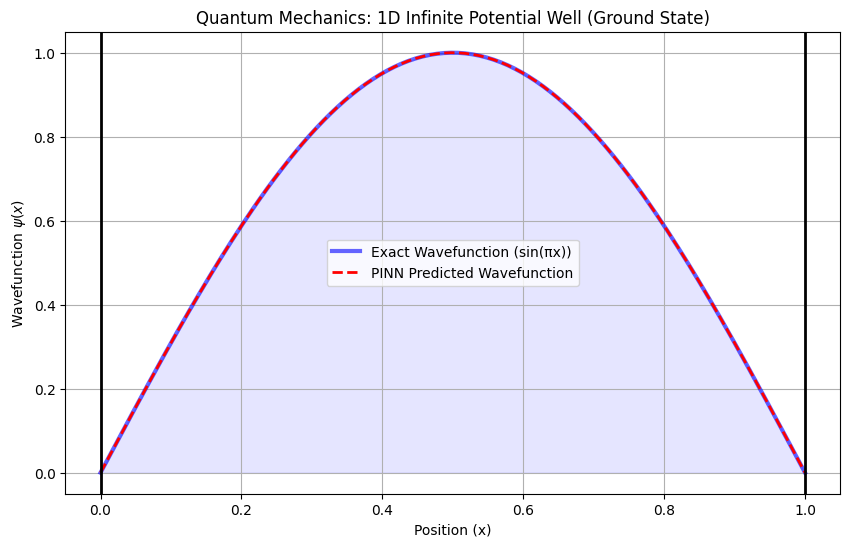

In [6]:
model.eval()
x_test = torch.linspace(0, 1, 200).view(-1, 1)

with torch.no_grad():
    psi_pred = model(x_test)
    
psi_exact = exact_wavefunction(x_test)

plt.figure(figsize=(10, 6))
plt.plot(x_test.numpy(), psi_exact.numpy(), label="Exact Wavefunction (sin(πx))", color="blue", linewidth=3, alpha=0.6)
plt.plot(x_test.numpy(), psi_pred.numpy(), '--', label="PINN Predicted Wavefunction", color="red", linewidth=2)

plt.fill_between(x_test.numpy().flatten(), psi_exact.numpy().flatten(), alpha=0.1, color='blue')
plt.axvline(0, color='black', linestyle='-', linewidth=2) # 势阱左壁
plt.axvline(1, color='black', linestyle='-', linewidth=2) # 势阱右壁
plt.xlabel("Position (x)")
plt.ylabel("Wavefunction $\psi(x)$")
plt.title("Quantum Mechanics: 1D Infinite Potential Well (Ground State)")
plt.legend()
plt.grid(True)
plt.show()